# Load cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# load data from global_weather_cleaded.csv

df = pd.read_csv('./global_weather_cleaned.csv')
df.shape

(143839, 41)

In [7]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 143839 entries, 0 to 143838
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       143839 non-null  str    
 1   location_name                 143839 non-null  str    
 2   latitude                      143839 non-null  float64
 3   longitude                     143839 non-null  float64
 4   timezone                      143839 non-null  str    
 5   last_updated_epoch            143839 non-null  int64  
 6   last_updated                  143839 non-null  str    
 7   temperature_celsius           143839 non-null  float64
 8   temperature_fahrenheit        143839 non-null  float64
 9   condition_text                143839 non-null  str    
 10  wind_mph                      143839 non-null  float64
 11  wind_kph                      143839 non-null  float64
 12  wind_degree                   143839 non-null  int64  


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,2026-05-27 04:50:00,2026-05-27 18:50:00,2026-05-27 12:12:00,2026-05-27 01:11:00,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,2026-05-27 05:21:00,2026-05-27 19:54:00,2026-05-27 12:58:00,2026-05-27 02:14:00,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,2026-05-27 05:40:00,2026-05-27 19:50:00,2026-05-27 13:15:00,2026-05-27 02:14:00,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,2026-05-27 06:31:00,2026-05-27 21:11:00,2026-05-27 14:12:00,2026-05-27 03:31:00,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,2026-05-27 06:12:00,2026-05-27 17:55:00,2026-05-27 13:17:00,2026-05-27 00:38:00,Waxing Gibbous,55


In [9]:
df.select_dtypes(include='number').columns

Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='str')

In [10]:
df.select_dtypes(exclude='number').columns

Index(['country', 'location_name', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='str')

In [ ]:
target_variable = 'temperature_celsius'

numerical_features = df.select_dtypes(include='number').columns.tolist()

categorical_features = df.select_dtypes(exclude='number').columns.tolist()

temporal_features = df.select_dtypes(
    include='datetime'
).columns.tolist()

# Correlation Analysis

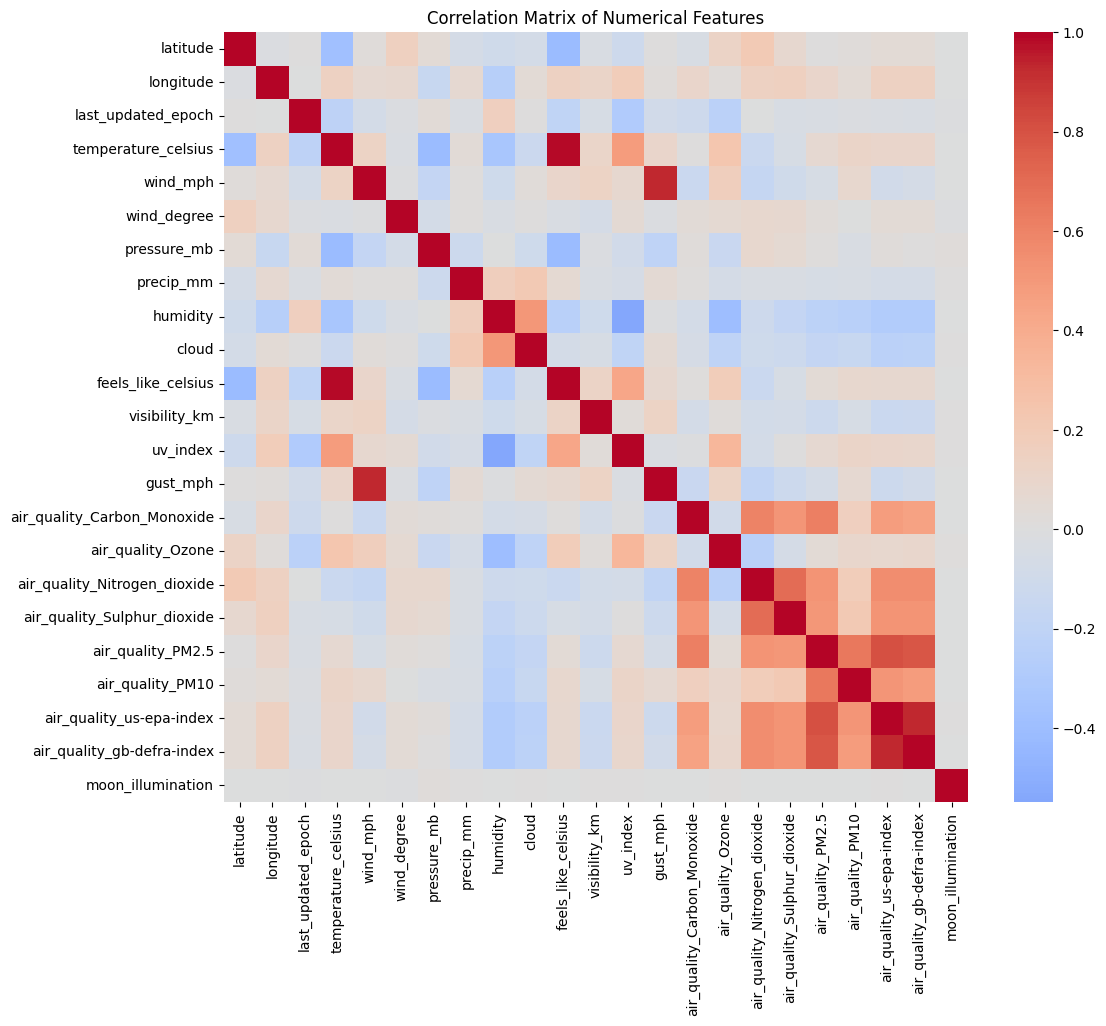

In [24]:
# checking correlation between numerical features

correlation_matrix = df[numerical_features].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

In [ ]:
temp_corr = correlation_matrix[
    'temperature_celsius'
].sort_values(ascending=False)

display(temp_corr.head(5))

temperature_celsius    1.000000
feels_like_celsius     0.983783
uv_index               0.488914
air_quality_Ozone      0.242130
longitude              0.141094
Name: temperature_celsius, dtype: float64

In [48]:
temp_corr = correlation_matrix[
    'temperature_celsius'
].sort_values(ascending=True)

display(temp_corr.head(5))

pressure_mb                    -0.418560
latitude                       -0.384539
humidity                       -0.338961
last_updated_epoch             -0.210503
air_quality_Nitrogen_dioxide   -0.133737
Name: temperature_celsius, dtype: float64

In [16]:
# Most highly correlated features are due to redundant measurements in different units
# Drop one of each pair of redundant features

redundant_feature_pairs = {
    'temperature': [
        'temperature_celsius',
        'temperature_fahrenheit'
    ],
    
    'wind_speed': [
        'wind_mph',
        'wind_kph'
    ],
    
    'pressure': [
        'pressure_mb',
        'pressure_in'
    ],
    
    'precipitation': [
        'precip_mm',
        'precip_in'
    ],
    
    'feels_like_temperature': [
        'feels_like_celsius',
        'feels_like_fahrenheit'
    ],
    
    'visibility': [
        'visibility_km',
        'visibility_miles'
    ],

    'gust_speed': [
        'gust_mph',
        'gust_kph'
    ]
}

columns_to_drop = [
    features[1]
    for features in redundant_feature_pairs.values()
]

df = df.drop(columns=columns_to_drop)

print(columns_to_drop)
print(df.shape)

['temperature_fahrenheit', 'wind_kph', 'pressure_in', 'precip_in', 'feels_like_fahrenheit', 'visibility_miles', 'gust_kph']
(143839, 34)


In [18]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

In [19]:
numerical_features = df.select_dtypes(include='number').columns.tolist()

geographical_features = [
    'country',
    'location_name',
    'latitude',
    'longitude',
    'timezone'
]

weather_features = [
    'temperature_celsius',
    'condition_text',
    'wind_mph',
    'wind_degree',
    'wind_direction',
    'pressure_mb',
    'precip_mm',
    'humidity',
    'cloud',
    'feels_like_celsius',
    'visibility_km',
    'uv_index',
    'gust_mph'
]

air_quality_features = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

astronomical_features = [
    'moon_phase',
    'moon_illumination'
]


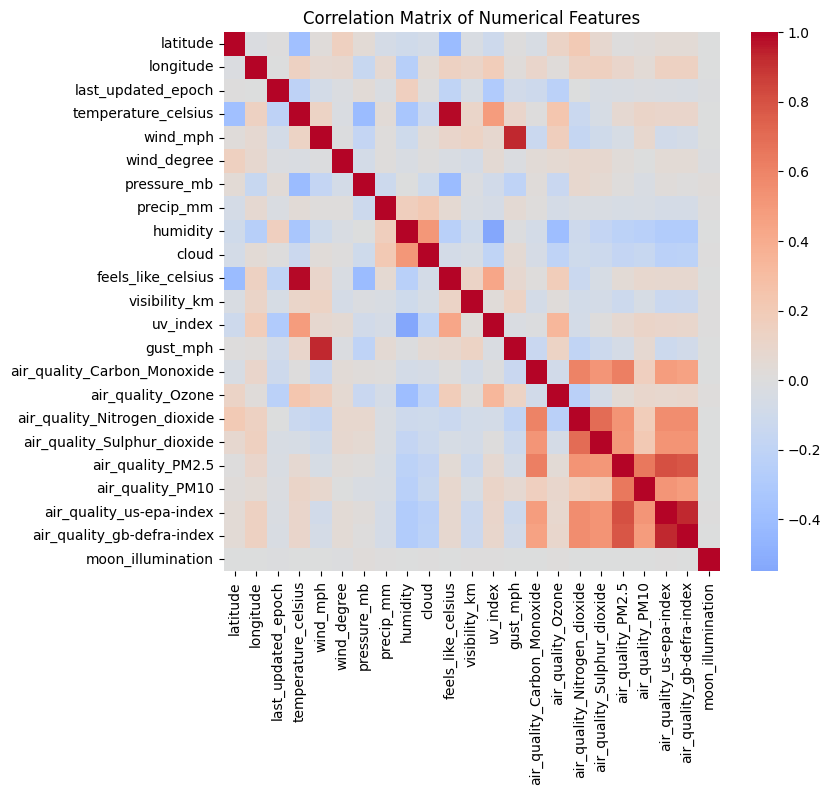

In [22]:
# checking correlation between numerical features after removing redundant features

correlation_matrix = df[numerical_features].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 7))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

Text(0.5, 1.0, 'Temperature vs Feels Like Temperature')

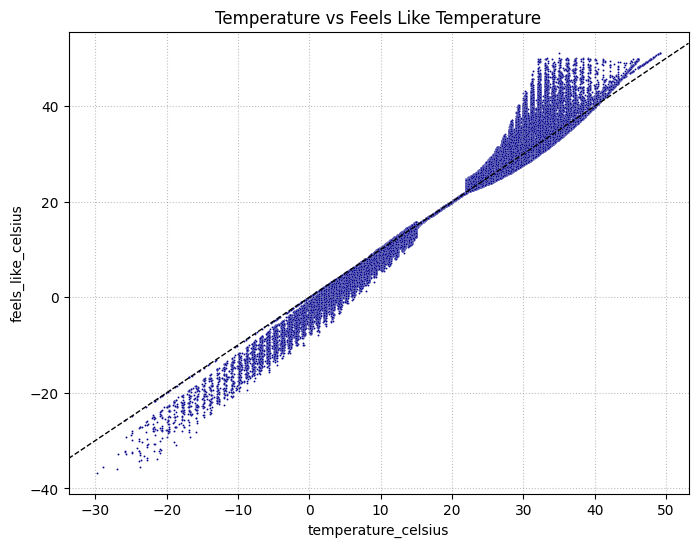

In [45]:
# plot temperature_celsius vs feels_like_celsius

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='temperature_celsius',
    y='feels_like_celsius',
    s=2,
    color='darkblue'
)
plt.grid(True, which='both', linestyle=':', alpha=0.5, color='gray')
plt.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1, label='x=y')

plt.title('Temperature vs Feels Like Temperature')

Although feels-like temperature exhibited strong correlation with actual temperature, exploratory analysis showed meaningful dispersion at temperature extremes, likely reflecting humidity and wind-chill effects. Therefore, the feature was retained during exploratory analysis and initial modeling preparation.

In [32]:
wind_corr = correlation_matrix[
    'wind_mph'
].sort_values(ascending=False)

display(wind_corr.head(5))

wind_mph               1.000000
gust_mph               0.930600
air_quality_Ozone      0.169078
visibility_km          0.127049
temperature_celsius    0.126075
Name: wind_mph, dtype: float64

Text(0.5, 1.0, 'Wind Speed vs Gust Speed')

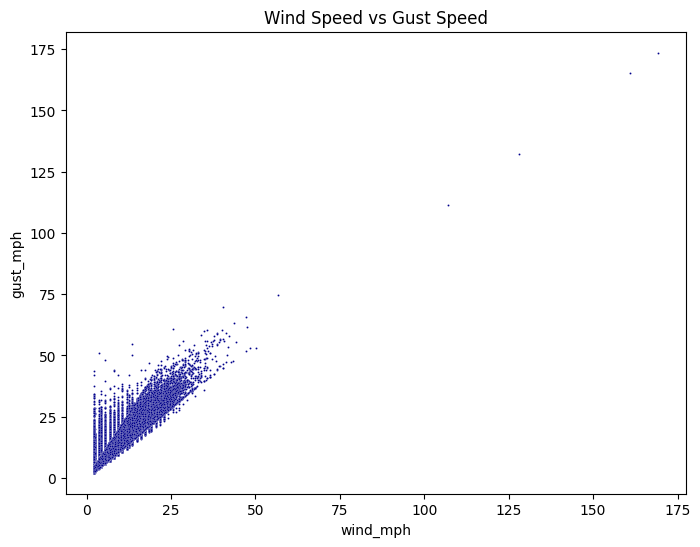

In [46]:
# plot wind_mph vs gust_mph

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='wind_mph',
    y='gust_mph',
    color='darkblue',
    s=2
)

plt.title('Wind Speed vs Gust Speed')

Wind speed and gust speed exhibited strong positive correlation (r ≈ 0.93). However, the scatterplot revealed substantial variability in gust intensity for a given sustained wind speed, indicating that gust measurements contain additional meteorological information rather than representing simple duplicates.

# Anamoly Detection

In [ ]:
# Removing feels_like_celsius and gust_mph as they are highly correlated with temperature_celsius and wind_mph respectively
# They do not add much additional information for predicting temperature_celsius and feels_like_celsius might leak target variable information

# df = df.drop(columns=['feels_like_celsius', 'gust_mph'])

In [ ]:
# moon_phase_order = [
#     'New Moon',
#     'Waxing Crescent',
#     'First Quarter',
#     'Waxing Gibbous',
#     'Full Moon',
#     'Waning Gibbous',
#     'Last Quarter',
#     'Waning Crescent'
# ]

# df['moon_phase'] = pd.Categorical(
#     df['moon_phase'],
#     categories=moon_phase_order,
#     ordered=True
# )

# phase_illumination = (
#     df.groupby('moon_phase')['moon_illumination']
#     .mean()
#     .reset_index()
# )

# plt.figure(figsize=(10,5))

# plt.plot(
#     phase_illumination['moon_phase'],
#     phase_illumination['moon_illumination'],
#     marker='o'
# )

# plt.xticks(rotation=45)
# plt.ylabel('Average Moon Illumination (%)')
# plt.title('Moon Illumination Across Moon Phases')

# plt.show()